# Assignment 1

![](https://media.giphy.com/media/xT9C25UNTwfZuk85WP/giphy-downsized-large.gif)

Remember the rules of ~Fight~ Code Club:
1. ALWAYS DOCUMENT
2. Cite resources that you use (paste links)
3. Include the names people who you worked with
4. Be neat and organized

## Scrape and Clean data

Based on you proposal, scrape or collect your data:

1. One variable must be either: (40 pts)
    1. scraped from the web OR;
    2. collected from an API AND you must create one new variable that is "new" to the best of your knowledge (combination of other variables representing something new).

2. You must have at least 3 variables, but you may include as many as you want into you final dataset. Likely, you will want to include more to make graphs and regressions. (30pts)

3. You must *be able* to run a regression that makes some sense with this data (the regression doesn't have to be a complete model). Briefly describe one regression you would run with your variables. (**DO NOT** run a regression, yet). (15pts)

4. You must have one combined and cleaned dataset (15 pts)

You must submit one python notebook on how you scraped/gathered data from an api, and how you combined and cleaned you data. I should be able to run your code and reproduce your final data set.  

The other variables that you choose to include do not have to be collected by API or webscraped, but you do have to combine the files and clean the dataset with python.

Thus, you must submit:
- Your finalized data set (only one) (note: you may add more variables in the future).
- Your documented python notebook
- Any associated data files needed to produce the final dataset.

You will be evaluated on:
- Completeness of the data
- Quality of the code 
- The creativity of the new variable/webscraped data you gather

Be sure to upload ALL associated files for your code to run. I will run your code from beginning to end - make it easy for me to replicate your code.

In [38]:
import requests

api_key = "d9eea423"

movie = "Interstellar"

#test API to see what the data looks like 
url = f"http://www.omdbapi.com/?t={movie}&apikey={api_key}"

response = requests.get(url)
data = response.json()

print(data)

{'Title': 'Interstellar', 'Year': '2014', 'Rated': 'PG-13', 'Released': '07 Nov 2014', 'Runtime': '169 min', 'Genre': 'Adventure, Drama, Sci-Fi', 'Director': 'Christopher Nolan', 'Writer': 'Jonathan Nolan, Christopher Nolan', 'Actors': 'Matthew McConaughey, Anne Hathaway, Jessica Chastain', 'Plot': 'When Earth becomes uninhabitable in the future, a farmer and ex-NASA pilot, Joseph Cooper, is tasked to pilot a spacecraft, along with a team of researchers, to find a new planet for humans.', 'Language': 'English', 'Country': 'United States, United Kingdom, Canada', 'Awards': 'Won 1 Oscar. 45 wins & 148 nominations total', 'Poster': 'https://m.media-amazon.com/images/M/MV5BYzdjMDAxZGItMjI2My00ODA1LTlkNzItOWFjMDU5ZDJlYWY3XkEyXkFqcGc@._V1_QL75_UX380_CR0,0,380,562_.jpg', 'Ratings': [{'Source': 'Internet Movie Database', 'Value': '8.7/10'}, {'Source': 'Rotten Tomatoes', 'Value': '73%'}, {'Source': 'Metacritic', 'Value': '74/100'}], 'Metascore': '74', 'imdbRating': '8.7', 'imdbVotes': '2,516,75

In [ ]:
import requests
import pandas as pd

api_key = "d9eea423"

movies = [
    "The Godfather",
    "Casablanca",
    "Citizen Kane",
    "Gone with the Wind",
    "Lawrence of Arabia",
    "The Wizard of Oz",
    "The Graduate",
    "On the Waterfront",
    "Schindler's List",
    "Singin' in the Rain",
    "It's a Wonderful Life",
    "Sunset Boulevard",
    "The Bridge on the River Kwai",
    "Some Like It Hot",
    "Star Wars",
    "All About Eve",
    "The African Queen",
    "Psycho",
    "Chinatown",
    "One Flew Over the Cuckoo's Nest",
    "The Grapes of Wrath",
    "2001: A Space Odyssey",
    "The Maltese Falcon",
    "Raging Bull",
    "E.T.",
    "Dr. Strangelove",
    "Bonnie and Clyde",
    "Apocalypse Now",
    "Mr. Smith Goes to Washington",
    "Treasure of the Sierra Madre",
    "Annie Hall",
    "The Godfather Part II",
    "High Noon",
    "To Kill a Mockingbird",
    "Rocky",
    "The Silence of the Lambs",
    "Network",
    "The Manchurian Candidate",
    "American Graffiti",
    "Raiders of the Lost Ark",
    "Vertigo",
    "Tootsie",
    "Stagecoach",
    "Close Encounters of the Third Kind",
    "The Philadelphia Story",
    "Shane",
    "It Happened One Night",
    "A Streetcar Named Desire",
    "Rear Window",
    "Forrest Gump",
    "The Shawshank Redemption",
    "Fight Club",
    "Interstellar",
    "The Matrix",
    "Pulp Fiction",
    "Goodfellas",
    "The Dark Knight",
    "Whiplash",
    "Parasite",
    "Joker",
    "Black Swan",
    "The Pianist",
    "The Green Mile",
    "Gladiator",
    "Memento",
    "The Prestige",
    "The Departed",
    "No Country for Old Men",
    "Arrival",
    "Blade Runner 2049",
    "Dune",
    "Oppenheimer",
    "Barbie",
    "Lady Bird",
    "Little Women",
    "The Notebook",
    "Manchester by the Sea",
    "Good Will Hunting",
    "Toy Story",
    "Coco",
    "Up",
    "Finding Nemo",
    "Wall-E",
    "Spirited Away",
    "Your Name",
    "City of God",
    "Seven Samurai",
    "Oldboy",
    "The Handmaiden",
    "Life Is Beautiful",
    "Pan's Labyrinth",
    "Roma",
    "Moonlight",
    "Minari",
    "Past Lives",
    "Portrait of a Lady on Fire",
    "Amélie",
    "The Florida Project",
    "Call Me by Your Name",
    "The Truman Show"
    ]
    
movie_data = []

#loop through each movie and get data from the API
for movie in movies:
    url = f"http://www.omdbapi.com/?t={movie}&apikey={api_key}"
    response = requests.get(url)
    data = response.json()

    #only keep valid responses
    if data["Response"] == "True":
        movie_data.append(data)

# turn everything into a dataframe
df = pd.DataFrame(movie_data)

#check
df

# I also tried using BeautifulSoup to scrape movie titles directly from an IMDb list page.
# The request connected successfully, but IMDb did not return the movie titles in a way that BeautifulSoup could easily extract.
# Because of that, I continued using the manually created list of 100 movie titles so the dataset would stay complete and consistent.

In [43]:
# Cleaning IMDb rating
df["imdbRating"] = pd.to_numeric(df["imdbRating"], errors="coerce")

# Makeing Runtime text first, then remove " min"
df["Runtime"] = df["Runtime"].astype(str)
df["Runtime"] = df["Runtime"].str.replace(" min", "")

# Turning Runtime into a number
df["Runtime"] = pd.to_numeric(df["Runtime"], errors="coerce")

df[["Title", "imdbRating", "Runtime"]]

,Title,imdbRating,Runtime
0,The Godfather,9.2,175.0
1,Casablanca,8.5,102.0
2,Citizen Kane,8.2,119.0
3,Gone with the Wind,8.2,238.0
4,Lawrence of Arabia,8.3,227.0
...,...,...,...
95,Portrait of a Lady on Fire,8.0,122.0
96,Amélie,8.3,122.0
97,The Florida Project,7.6,111.0
98,Call Me by Your Name,7.8,132.0


In [44]:
#function to turn the Awards text into a number
def awards_count(text): 
    if text == "N/A":
        return 0
    
    total = 0
    words = text.split()

    #go through each word and add numbers we find
    for w in words:
        if w.isdigit():
            total += int(w)
    
    return total

#apply function to create total awards column
df["Awards_Count"] = df["Awards"].apply(awards_count)


In [45]:
df["Genre_Count"] = df["Genre"].apply(lambda x: len(x.split(",")))  #count how many genres each movie has

In [46]:
df_final = df[[   #keep only important columns
    "Title",
    "Year",
    "imdbRating",
    "Runtime",
    "Awards",
    "Awards_Count",
    "Genre",
    "Genre_Count"
]]

df_final

,Title,Year,imdbRating,Runtime,Awards,Awards_Count,Genre,Genre_Count
0,The Godfather,1972,9.2,175.0,Won 3 Oscars. 31 wins & 31 nominations total,65,"Crime, Drama",2
1,Casablanca,1943,8.5,102.0,Won 3 Oscars. 18 wins & 12 nominations total,33,"Drama, Romance, War",3
2,Citizen Kane,1941,8.2,119.0,Won 1 Oscar. 16 wins & 13 nominations total,30,"Drama, Mystery",2
3,Gone with the Wind,1939,8.2,238.0,Won 8 Oscars. 26 wins & 10 nominations total,44,"Drama, Romance, War",3
4,Lawrence of Arabia,1962,8.3,227.0,Won 7 Oscars. 31 wins & 14 nominations total,52,"Adventure, Biography, Drama",3
...,...,...,...,...,...,...,...,...
95,Portrait of a Lady on Fire,2020,8.0,122.0,Nominated for 1 BAFTA Award. 59 wins & 155 nom...,215,"Drama, Romance",2
96,Amélie,2002,8.3,122.0,Nominated for 5 Oscars. 60 wins & 74 nominatio...,139,"Comedy, Romance",2
97,The Florida Project,2017,7.6,111.0,Nominated for 1 Oscar. 68 wins & 134 nominatio...,203,Drama,1
98,Call Me by Your Name,2017,7.8,132.0,Won 1 Oscar. 107 wins & 263 nominations total,371,"Drama, Romance",2


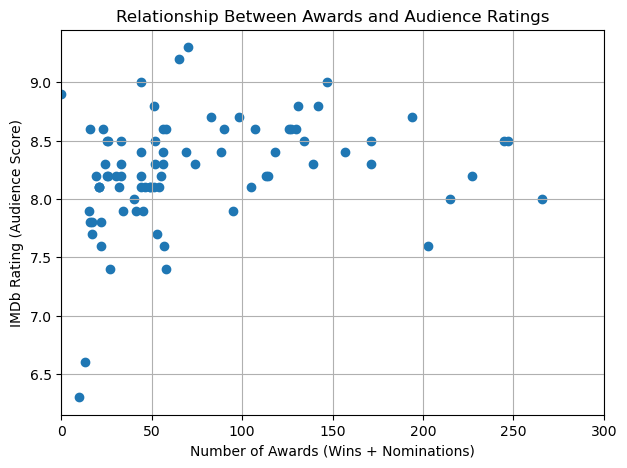

In [47]:
import matplotlib.pyplot as plt #used to create graphs and visualize the data
plt.figure(figsize=(7,5)) #make the plot a bit bigger so it's easier to see

plt.scatter(df_final["Awards_Count"], df_final["imdbRating"]) #plot awords vs rating to see if there's any relationship

plt.xlim(0, 300) #cut off really high values so the graph looks cleaner

plt.xlabel("Number of Awards (Wins + Nominations)") #labels
plt.ylabel("IMDb Rating (Audience Score)") #labels
plt.title("Relationship Between Awards and Audience Ratings") #title

plt.grid(True) #grid helps read it better

plt.show() #show the plot

In [49]:
# save final dataset as csv for Assignment 3
df_final.to_csv("movies_final.csv", index=False)

The scatter plot shows the relationship between the number of awards a movie received and its IMDb rating. While movies with more awards may be expected to have higher ratings, the graph does not show a very strong linear relationship. Many highly rated movies fall within a moderate award range, while some movies with a very large number of awards do not necessarily have the highest ratings. This suggests that audience ratings and award recognition do not always perfectly match.

I would run a simple linear regression where IMDb rating is the dependent variable and the number of awards is the independent variable to see whether movies with more awards tend to receive higher audience ratings.